## Summary

This notebook implements a conditional normalizing flow in JAX to model $p(\text{dE/dx} | R)$.

**Key steps:**
1. Load edepsim segment data and extract (range, dE/dx) pairs.
2. Normalize and split into train/validation.
3. Define a simple affine coupling-based conditional flow.
4. Train with negative log-likelihood loss using JAX's autodiff and JIT.
5. Evaluate on validation set and sample from the learned distribution.
6. Visualize results: loss curves, empirical vs. sampled distributions, and 2D histograms.

**Next steps:**
- Refine the flow architecture (e.g., use masked autoencoders, more coupling layers).
- Experiment with different normalizations and data augmentation.
- Compute posterior predictive checks and calibration metrics.
- Save/load trained models for inference.

# Conditional Normalizing Flow: Range R → dE/dx Distribution

Fit a 2D histogram of (range R, dE/dx) using a conditional normalizing flow in JAX.
This model learns to output dE/dx distributions conditioned on a given residual range value.

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

import h5py
import numpy as np
import jax
import jax.numpy as jnp
from jax import Array, jit, grad, vmap
from functools import partial
import matplotlib.pyplot as plt
from pathlib import Path

import equinox as eqx

if not hasattr(jax.random, 'KeyArray'):
    jax.random.KeyArray = Array

from flowjax.bijections import RationalQuadraticSpline
from flowjax.distributions import StandardNormal
from flowjax.flows import masked_autoregressive_flow

# Set random seed for reproducibility
rng_key = jax.random.PRNGKey(42)

plt.rcParams.update({'font.size': 16})

# Alternatively, customize specific elements globally
plt.rcParams.update({
    'axes.titlesize': 22,   # Title size
    'axes.labelsize': 18,   # X and Y label size
    'xtick.labelsize': 14,  # X tick size
    'ytick.labelsize': 14,  # Y tick size
    'legend.fontsize': 18   # Legend size
})


/sdf/home/c/cyifan/.local/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.3 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(
ERROR:2026-06-16 16:52:16,285:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/sdf/home/c/cyifan/.local/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/sdf/home/c/cyifan/.local/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/sdf/home/c/cyifan/.local/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versio

## 1. Load Segment Data from HDF5

Load the edepsim output, extract segments, and fetch the range and dE/dx fields.

In [2]:
# stopping proton 0.1mm
fname_lbl_01mm = "/sdf/data/neutrino/cyifan/dunend_train_prod/prod_mod0_mpvmpr/production_3557923/job_23705529_0000/output_23705529_0000-edepsim_lbl_range_0.05cm.h5"
tag = "stopping_proton_dx0.1mm"

# # stopping muon 0.1mm
# fname_lbl_01mm = "/sdf/data/neutrino/cyifan/dunend_train_prod/prod_mod0_mpvmpr/production_3543042/job_23756464_0000/output_23756464_0000-edepsim_lbl_range_0.05cm.h5"
# tag = "stopping_muon_dx0.1mm"

# # through-going muon 0.1mm
# fname_lbl_01mm = "/sdf/data/neutrino/cyifan/dunend_train_prod/prod_mod0_mpvmpr/production_3576201/job_23729838_0000/output_23729838_0000-edepsim_lbl_range_0.05cm.h5"
# tag = "throughgoing_muon_dx0.1mm"

# Through-going muons are treated as range-independent: train unconditional 1D flow.
is_throughgoing_muon = tag.startswith("throughgoing_muon")
flow_condition_mode = "unconditional" if is_throughgoing_muon else "conditional"
flow_cond_dim = 0 if is_throughgoing_muon else 1
print(f"Flow condition mode: {flow_condition_mode} (cond_dim={flow_cond_dim})")

with h5py.File(fname_lbl_01mm, 'r') as f:
    seg_lbl_01 = f['segments'][:]

# Extract range and dE/dx fields
range_data = seg_lbl_01['range']
dedx_data = seg_lbl_01['dEdx']

print(f"Loaded {len(range_data)} segments")
print(f"Range: min={range_data.min():.4f}, max={range_data.max():.4f}")
print(f"dE/dx: min={dedx_data.min():.4f}, max={dedx_data.max():.4f}")
print(f"Data shapes: range={range_data.shape}, dedx={dedx_data.shape}")

Flow condition mode: conditional (cond_dim=1)
Loaded 3653236 segments
Range: min=0.0500, max=11.7668
dE/dx: min=3.1020, max=75.4342
Data shapes: range=(3653236,), dedx=(3653236,)


In [ ]:
# # Added loader for stopping_proton_dx0.1mm from wildcard job files (does not overwrite existing cells).
# from glob import glob

# tag = "stopping_proton_dx0.1mm"
# pattern = (
#     "/sdf/data/neutrino/cyifan/dunend_train_prod/prod_mod0_mpvmpr/"
#     "production_3978808/job_*/output_*-edepsim_lbl_range_0.05cm.h5"
# )
# files = sorted(glob(pattern))

# if not files:
#     raise FileNotFoundError(f"No files matched pattern: {pattern}")

# range_chunks = []
# dedx_chunks = []
# n_segments_total = 0

# for fpath in files:
#     with h5py.File(fpath, "r") as f:
#         seg = f["segments"][:]
#     range_chunks.append(seg["range"].astype(np.float32))
#     dedx_chunks.append(seg["dEdx"].astype(np.float32))
#     n_segments_total += seg.shape[0]

# range_data = np.concatenate(range_chunks, axis=0)
# dedx_data = np.concatenate(dedx_chunks, axis=0)

# print(f"tag={tag}")
# print(f"Matched files: {len(files)}")
# print(f"Total segments read: {n_segments_total}")
# print(f"range_data shape={range_data.shape}, min={range_data.min():.4f}, max={range_data.max():.4f}")
# print(f"dedx_data shape={dedx_data.shape}, min={dedx_data.min():.4f}, max={dedx_data.max():.4f}")

## 2. Build R and dE/dx Training Arrays

Clean the data, remove invalid entries, and assemble paired training samples.

In [3]:
# Remove NaN and invalid values.
# Through-going muons can have negative residual range and signed dE/dx;
# for flow training we use |dE/dx| as the physical magnitude.
if is_throughgoing_muon:
    dedx_source = np.abs(dedx_data)
    mask = np.isfinite(range_data) & np.isfinite(dedx_source) & (dedx_source > 0)
else:
    dedx_source = dedx_data
    mask = np.isfinite(range_data) & np.isfinite(dedx_source) & (range_data > 0) & (dedx_source > 0)

R_clean = range_data[mask].astype(np.float32)
dEdx_clean = dedx_source[mask].astype(np.float32)

print(f"After cleaning: {len(R_clean)} valid samples")
if len(R_clean) == 0:
    raise ValueError("No valid samples after filtering. Check sign/units of range and dE/dx in input data.")
print(f"Range: min={R_clean.min():.4f}, max={R_clean.max():.4f}")
print(f"dE/dx: min={dEdx_clean.min():.4f}, max={dEdx_clean.max():.4f}")

# Assemble paired training samples
data_pairs = np.column_stack([R_clean, dEdx_clean])
print(f"Training data shape: {data_pairs.shape}")

After cleaning: 3653236 valid samples
Range: min=0.0500, max=11.7668
dE/dx: min=3.1020, max=75.4342
Training data shape: (3653236, 2)


## 3. Normalize Variables and Split Train/Validation Sets

Standardize R and dE/dx, then split into training and validation subsets.

In [ ]:
# Compute normalization statistics
R_mean = float(R_clean.mean())
R_std = float(R_clean.std())
if R_std < 1e-12:
    R_std = 1.0

# Train in log-space to enforce strictly positive physical dE/dx at inference.
eps = 1e-8
dEdx_log = np.log(dEdx_clean + eps)
dEdx_mean, dEdx_std = float(dEdx_log.mean()), float(dEdx_log.std())
if dEdx_std < 1e-12:
    dEdx_std = 1.0

print("Normalization stats:")
print(f"  R: mean={R_mean:.4f}, std={R_std:.4f}")
print(f"  log(dEdx): mean={dEdx_mean:.4f}, std={dEdx_std:.4f}")

# Normalize data: [R_norm, log(dEdx)_norm]
data_normalized = data_pairs.copy()
if flow_cond_dim > 0:
    data_normalized[:, 0] = (R_clean - R_mean) / R_std
else:
    # Unconditional flow path: condition is unused, keep a stable dummy channel.
    data_normalized[:, 0] = 0.0
data_normalized[:, 1] = (dEdx_log - dEdx_mean) / dEdx_std

# Split into train/validation
n_total = len(data_normalized)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

# Shuffle
perm = np.random.permutation(n_total)
data_normalized = data_normalized[perm]

data_train = data_normalized[:n_train]
data_val = data_normalized[n_train:]

print(f"Train: {n_train}, Validation: {n_val}")

# Store normalization params for later use
norm_params = {
    'R_mean': R_mean,
    'R_std': R_std,
    'dEdx_log_mean': dEdx_mean,
    'dEdx_log_std': dEdx_std,
    'dEdx_eps': eps,
}

Normalization stats:
  R: mean=-23.5362, std=18.8863
  log(dEdx): mean=0.4886, std=0.4258
Train: 26965769, Validation: 6741443


## 4. Define the Conditional Normalizing Flow in JAX

Implement a simple conditional flow: $p(y|x) = p_0(z) \left|\frac{dz}{dy}\right|$, where $z = T_\theta(y; x)$.

In [ ]:
def make_flow(key, hidden_dim=64, n_layers=3, cond_dim=1):

    flow = masked_autoregressive_flow(
        key=key,
        base_dist=StandardNormal((1,)),
        transformer=RationalQuadraticSpline(knots=8, interval=5.0),
        cond_dim=cond_dim,
        flow_layers=6,
        nn_width=hidden_dim,
        nn_depth=n_layers,
        # invert=True,
    )
    return flow

def make_flow_params(key, hidden_dim=64, n_layers=3):
    """Initialize parameters for a simple conditional neural network transform."""
    keys = jax.random.split(key, 2 * n_layers + 1)
    params = {}
    
    # Layers: condition_embedding -> hidden layers -> output
    # Embedding layer: (condition) -> hidden_dim
    params['embed_w'] = jax.random.normal(keys[0], (1, hidden_dim)) * 0.01
    params['embed_b'] = jnp.zeros(hidden_dim)
    
    # Hidden layers: each takes (hidden_dim + input_dim) and outputs hidden_dim
    for i in range(n_layers):
        in_dim = hidden_dim
        # in_dim = hidden_dim + 1 if i == 0 else hidden_dim
        params[f'w{i}'] = jax.random.normal(keys[i+1], (in_dim, hidden_dim)) * 0.01
        params[f'b{i}'] = jnp.zeros(hidden_dim)
    
    # Output layer: maps to (scale, shift) for affine coupling
    params['w_out'] = jax.random.normal(keys[-1], (hidden_dim, 2)) * 0.01
    params['b_out'] = jnp.zeros(2)
    
    return params

def affine_coupling_forward(y, condition, params, key):
    """Simple affine coupling: z = scale * y + shift, with scale, shift conditioned on x."""
    # Embed condition
    h = jnp.tanh(jnp.dot(jnp.array([[condition]]), params['embed_w']) + params['embed_b']).squeeze()
    x = h
    for i in range(3):
        x = jnp.tanh(jnp.dot(x, params[f'w{i}']) + params[f'b{i}'])
    scale_shift = jnp.dot(x, params['w_out']) + params['b_out']
    log_scale, shift = scale_shift[0], scale_shift[1]
    scale = jnp.exp(jnp.clip(log_scale, -3, 3))
    return scale * y + shift, log_scale

def affine_coupling_inverse(z, condition, params, key):
    h = jnp.tanh(jnp.dot(jnp.array([[condition]]), params['embed_w']) + params['embed_b']).squeeze()
    x = h
    for i in range(3):
        x = jnp.tanh(jnp.dot(x, params[f'w{i}']) + params[f'b{i}'])
    scale_shift = jnp.dot(x, params['w_out']) + params['b_out']
    log_scale, shift = scale_shift[0], scale_shift[1]
    scale = jnp.exp(jnp.clip(log_scale, -3, 3))
    return (z - shift) / scale

def standard_normal_logpdf(z):
    """Log-density of standard normal."""
    return -0.5 * (z**2 + jnp.log(2 * jnp.pi))

print(f"Flow architecture defined (cond_dim={flow_cond_dim}).")

Flow architecture defined (cond_dim=0).


## 5. Create the Log-Likelihood Loss and Training Step

Negative log-likelihood for conditional density estimation with JIT and autodiff.

In [ ]:
def _empty_condition(n_rows=None):
    """FlowJAX expects a condition array when cond_shape is not None, even for cond_dim=0."""
    if n_rows is None:
        return jnp.zeros((0,), dtype=jnp.float32)
    return jnp.zeros((n_rows, 0), dtype=jnp.float32)


def nll_loss_single(y, condition, flow, params, key, flow_type='flowjax'):
    if flow_type == 'flowjax':
        del flow, key
        y_arr = jnp.atleast_1d(y)
        if flow_cond_dim > 0:
            cond_arr = jnp.atleast_1d(condition)
        else:
            cond_arr = _empty_condition()
        log_py = params.log_prob(y_arr, condition=cond_arr)
        return -log_py
    else:
        z, log_det_jac = affine_coupling_forward(y, condition, params, key)
        log_pz = standard_normal_logpdf(z)
        log_py = log_pz + log_det_jac
        return -log_py


def nll_loss_batch(batch, flow, key, flow_type='flowjax'):
    conditions = batch[:, 0]
    ys = batch[:, 1]
    if flow_type == 'flowjax':
        y_arr = ys[:, None]
        if flow_cond_dim > 0:
            cond_arr = conditions[:, None]
        else:
            cond_arr = _empty_condition(y_arr.shape[0])
        log_py = flow.log_prob(y_arr, condition=cond_arr)
        return -jnp.mean(log_py)
    else:
        keys = jax.random.split(key, len(batch))
        losses = vmap(lambda c, y, k: nll_loss_single(y, c, flow, flow, k, flow_type))(conditions, ys, keys)
        return jnp.mean(losses)

print(f"Loss and training functions defined (cond_dim={flow_cond_dim}).")

Loss and training functions defined (cond_dim=0).


## 6. Train the Model with JIT and Optimizer State

Run the training loop with Adam optimizer, track losses, and save best model.

In [ ]:
import optax

flow_type = 'flowjax'  # flowjax or affine

# Initialize model and optimizer (self-contained training cell)
rng_key, subkey = jax.random.split(rng_key)
if flow_type == 'flowjax':
    model = make_flow(subkey, cond_dim=flow_cond_dim)
else:
    model = make_flow_params(subkey, hidden_dim=64, n_layers=3)

# Training configuration
n_epochs = 50
batch_size = 16384
#batch_size = 4096

# Keep datasets on CPU as float32; move only the active batch to JAX/GPU.
data_train_cpu = np.asarray(data_train, dtype=np.float32)
data_val_cpu = np.asarray(data_val, dtype=np.float32)
n_batches = int(np.ceil(len(data_train_cpu) / batch_size))

# Learning-rate scheduler: linear warmup + cosine decay
lr_peak = 1e-3
lr_end = 1e-5
warmup_epochs = 5
warmup_steps = max(1, warmup_epochs * n_batches)
decay_steps = max(1, (n_epochs - warmup_epochs) * n_batches)
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=lr_peak,
    warmup_steps=warmup_steps,
    decay_steps=decay_steps,
    end_value=lr_end,
)
optimizer = optax.adam(lr_schedule)
optimizer_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array) if flow_type == 'flowjax' else model)

train_losses = []
val_losses = []
lr_history = []
best_val_loss = float('inf')
best_params = jax.tree_util.tree_map(lambda x: jnp.array(x) if eqx.is_inexact_array(x) else x, model)

val_loss_fn = eqx.filter_jit(lambda f, batch, key: nll_loss_batch(batch, f, key, flow_type))

def to_device_batch(batch_cpu):
    return jnp.asarray(batch_cpu, dtype=jnp.float32)

def eval_loss_cpu(model, data_cpu, rng_key, batch_size):
    total_loss = 0.0
    total_examples = 0
    for start in range(0, len(data_cpu), batch_size):
        stop = min(start + batch_size, len(data_cpu))
        batch_cpu = data_cpu[start:stop]
        batch = to_device_batch(batch_cpu)
        rng_key, subkey = jax.random.split(rng_key)
        batch_loss = float(val_loss_fn(model, batch, subkey))
        total_loss += batch_loss * len(batch_cpu)
        total_examples += len(batch_cpu)
    return total_loss / total_examples, rng_key

if flow_type == 'flowjax':
    @eqx.filter_jit
    def train_step_impl(batch, model, optimizer_state, key):
        def loss_fn(f):
            return nll_loss_batch(batch, f, key, flow_type)
        
        loss, grads = eqx.filter_value_and_grad(loss_fn)(model)
        updates, new_opt_state = optimizer.update(
            grads,
            optimizer_state,
            eqx.filter(model, eqx.is_inexact_array)
        )
        new_model = eqx.apply_updates(model, updates)
        return loss, new_model, new_opt_state
else:
    @jax.jit
    def train_step_impl(batch, model, optimizer_state, key):
        loss_fn = lambda f: nll_loss_batch(batch, f, key, flow_type)
        loss, grads = jax.value_and_grad(loss_fn)(model)
        updates, new_opt_state = optimizer.update(grads, optimizer_state, model)
        new_model = optax.apply_updates(model, updates)
        return loss, new_model, new_opt_state

print(f"Starting training with condition_mode={flow_condition_mode} (cond_dim={flow_cond_dim})...")
global_step = 0
for epoch in range(n_epochs):
    rng_key, subkey = jax.random.split(rng_key)
    epoch_seed = int(jax.random.randint(subkey, (), 0, np.iinfo(np.int32).max))
    perm = np.random.default_rng(epoch_seed).permutation(len(data_train_cpu))

    epoch_losses = []
    epoch_lrs = []
    for i in range(n_batches):
        batch_indices = perm[i * batch_size : min((i + 1) * batch_size, len(data_train_cpu))]
        batch_cpu = data_train_cpu[batch_indices]
        batch = to_device_batch(batch_cpu)
        rng_key, subkey = jax.random.split(rng_key)
        loss, model, optimizer_state = train_step_impl(batch, model, optimizer_state, subkey)
        epoch_losses.append(float(loss))

        current_lr = float(lr_schedule(global_step))
        epoch_lrs.append(current_lr)
        lr_history.append(current_lr)
        global_step += 1

    train_epoch_loss = float(np.mean(epoch_losses))
    if jnp.isnan(train_epoch_loss):
        print(f"NaN at epoch {epoch + 1}, stopping")
        break

    val_loss, rng_key = eval_loss_cpu(model, data_val_cpu, rng_key, batch_size)

    train_losses.append(train_epoch_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_params = jax.tree_util.tree_map(lambda x: x.copy() if hasattr(x, 'copy') else x, model)

    if (epoch + 1) % 5 == 0:
        epoch_lr = float(np.mean(epoch_lrs)) if len(epoch_lrs) else float(lr_schedule(global_step))
        print(f"Epoch {epoch + 1}: train={train_epoch_loss:.4f}, val={val_loss:.4f}, lr={epoch_lr:.2e}")

# Keep the trained model available for later notebook cells.
flow = model

print(f"Training complete. Best val loss: {best_val_loss:.4f}")

Starting training with condition_mode=unconditional (cond_dim=0)...
Epoch 5: train=1.2094, val=1.2092, lr=9.00e-04
Epoch 10: train=1.2092, val=1.2091, lr=9.69e-04
Epoch 15: train=1.2091, val=1.2090, lr=8.68e-04
Epoch 20: train=1.2091, val=1.2089, lr=7.12e-04
Epoch 25: train=1.2091, val=1.2090, lr=5.24e-04
Epoch 30: train=1.2090, val=1.2089, lr=3.34e-04
Epoch 35: train=1.2090, val=1.2089, lr=1.69e-04
Epoch 40: train=1.2090, val=1.2089, lr=5.56e-05
Epoch 45: train=inf, val=inf, lr=1.05e-05
Epoch 50: train=inf, val=inf, lr=1.00e-05
Training complete. Best val loss: 1.2089


## 7. Evaluate Conditional Density Quality

Compare learned vs. empirical distributions on validation bins.

In [ ]:
# Evaluate on validation set in physical units.
R_val_phys = data_val[:, 0] * float(R_std) + float(R_mean)
dEdx_val_phys = np.exp(data_val[:, 1] * float(dEdx_std) + float(dEdx_mean))

if flow_cond_dim == 0:
    print("Unconditional flow: no R-conditioned validation bins to report.")
    print(
        f"Validation dE/dx mean={dEdx_val_phys.mean():.6f}, std={dEdx_val_phys.std():.6f}, "
        f"count={len(dEdx_val_phys)}"
    )
else:
    n_bins_condition = 5
    R_edges = np.linspace(R_val_phys.min(), R_val_phys.max(), n_bins_condition + 1)

    print("Validation set statistics by physical R bin:")
    print(f"{'R bin [cm]':<30} {'Empirical dE/dx':<20} {'Count':<10}")

    empirical_stats = {}
    for i in range(n_bins_condition):
        mask = (R_val_phys >= R_edges[i]) & (R_val_phys < R_edges[i + 1])
        if mask.sum() > 0:
            empirical_mean = dEdx_val_phys[mask].mean()
            count = int(mask.sum())
            empirical_stats[i] = (float(empirical_mean), count)
            print(f"[{R_edges[i]:.3f}, {R_edges[i+1]:.3f}]  {empirical_mean:.6f}  {count}")

print("\nEvaluation complete.")

Unconditional flow: no R-conditioned validation bins to report.
Validation dE/dx mean=1.876086, std=1.884884, count=6741443

Evaluation complete.


## 8. Sample dE/dx Distributions at Fixed R Values

Generate samples from the learned conditional flow at selected R values.

In [ ]:
def _ensure_typed_key(key):
    """Convert legacy uint32 PRNGKey to new typed key when required by FlowJAX/JAX."""
    if not hasattr(jax.random, "key"):
        return key

    try:
        if jax.dtypes.issubdtype(key.dtype, jax.dtypes.prng_key):
            return key
    except Exception:
        pass

    # Legacy key path: derive a stable seed from raw uint32 key data.
    key_data = np.asarray(key, dtype=np.uint32).reshape(-1)
    if key_data.size >= 2:
        seed64 = (np.uint64(key_data[0]) << np.uint64(32)) ^ np.uint64(key_data[1])
    elif key_data.size == 1:
        seed64 = np.uint64(key_data[0])
    else:
        seed64 = np.uint64(0)
    seed = int(seed64 % np.uint64(np.iinfo(np.uint32).max))
    return jax.random.key(seed)


def sample_conditional(condition_normalized, n_samples, params, key, flow=None, flow_type='flowjax'):
    key = _ensure_typed_key(key)
    conditions = jnp.asarray(condition_normalized, dtype=jnp.float32)

    if flow_type == 'flowjax':
        # Unconditional path: ignore condition and draw directly.
        if flow_cond_dim == 0:
            samples = flow.sample(key, sample_shape=(n_samples,))
            return jnp.asarray(samples).reshape(-1)

        # Scalar condition -> sample n_samples from one conditional distribution.
        if conditions.ndim == 0:
            condition_1d = jnp.asarray([conditions], dtype=jnp.float32)  # shape (1,)
            samples = flow.sample(key, sample_shape=(n_samples,), condition=condition_1d)
            return jnp.asarray(samples).reshape(-1)

        # Vector conditions -> sample one value per condition.
        conditions = conditions.reshape(-1)
        if int(conditions.shape[0]) != int(n_samples):
            raise ValueError(
                f"For batched conditions, n_samples must equal len(condition_normalized). "
                f"Got n_samples={n_samples}, len={int(conditions.shape[0])}."
            )
        condition_2d = conditions[:, None]  # shape (N, 1)
        samples = flow.sample(key, sample_shape=(), condition=condition_2d)
        return jnp.asarray(samples).reshape(-1)
    else:
        if conditions.ndim == 0:
            conditions = jnp.full((n_samples,), conditions, dtype=jnp.float32)
        else:
            conditions = conditions.reshape(-1)
            if int(conditions.shape[0]) != int(n_samples):
                raise ValueError(
                    f"For batched conditions, n_samples must equal len(condition_normalized). "
                    f"Got n_samples={n_samples}, len={int(conditions.shape[0])}."
                )
        keys = jax.random.split(key, n_samples)
        z_samples = jax.random.normal(key, (n_samples,), dtype=jnp.float32)
        return vmap(
            lambda z, c, k: affine_coupling_inverse(z, c, params, k)
        )(z_samples, conditions, keys)

# Choose physical-R values, then normalize for conditioning the flow.
R_test_values_phys = np.linspace(float(R_clean.min()), float(R_clean.max()), 3)
R_test_values_norm = (R_test_values_phys - float(R_mean)) / float(R_std)
n_samples_per_R = 1000

eps = float(norm_params.get('dEdx_eps', 1e-8))

rng_key, subkey = jax.random.split(rng_key)

sampled_distributions = {}
for R_phys, R_norm in zip(R_test_values_phys, R_test_values_norm):
    rng_key, subkey = jax.random.split(rng_key)

    # Model output is normalized log(dE/dx).
    samples_norm = sample_conditional(float(R_norm), n_samples_per_R, best_params, subkey, flow=flow, flow_type=flow_type)

    # Convert prediction back to physical dE/dx: exp(log dE/dx).
    samples_log = np.array(samples_norm) * float(dEdx_std) + float(dEdx_mean)
    samples_phys = np.exp(samples_log) - eps
    samples_phys = np.clip(samples_phys, 0.0, None)

    sampled_distributions[float(R_phys)] = samples_phys
    print(
        f"Sampled {n_samples_per_R} dE/dx values for R={R_phys:.4f} cm "
        f"(norm={R_norm:.4f}): mean={samples_phys.mean():.4f}, std={samples_phys.std():.4f}, "
        f"min={samples_phys.min():.4f}"
    )

print("Sampling complete.")

2026-05-21 00:51:17.689075: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-05-21 00:51:17.689120: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


Sampled 1000 dE/dx values for R=0.0500 cm (norm=-1.1475): mean=65.1623, std=3.1372, min=52.8077
Sampled 1000 dE/dx values for R=28.8999 cm (norm=3.3272): mean=4.2342, std=2.6696, min=1.9829
Sampled 1000 dE/dx values for R=57.7498 cm (norm=7.8018): mean=3.2594, std=2.1001, min=1.4295
Sampling complete.


## 9. Visualize Learned and True Distributions

Plot 2D histogram, loss curves, and conditional slices.

Plotting with in-memory flow model (best_params/flow).
In-memory model missing; auto-loaded stored flow model: /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/dedx_flow_model_stopping_muon_dx0.1mm.eqx


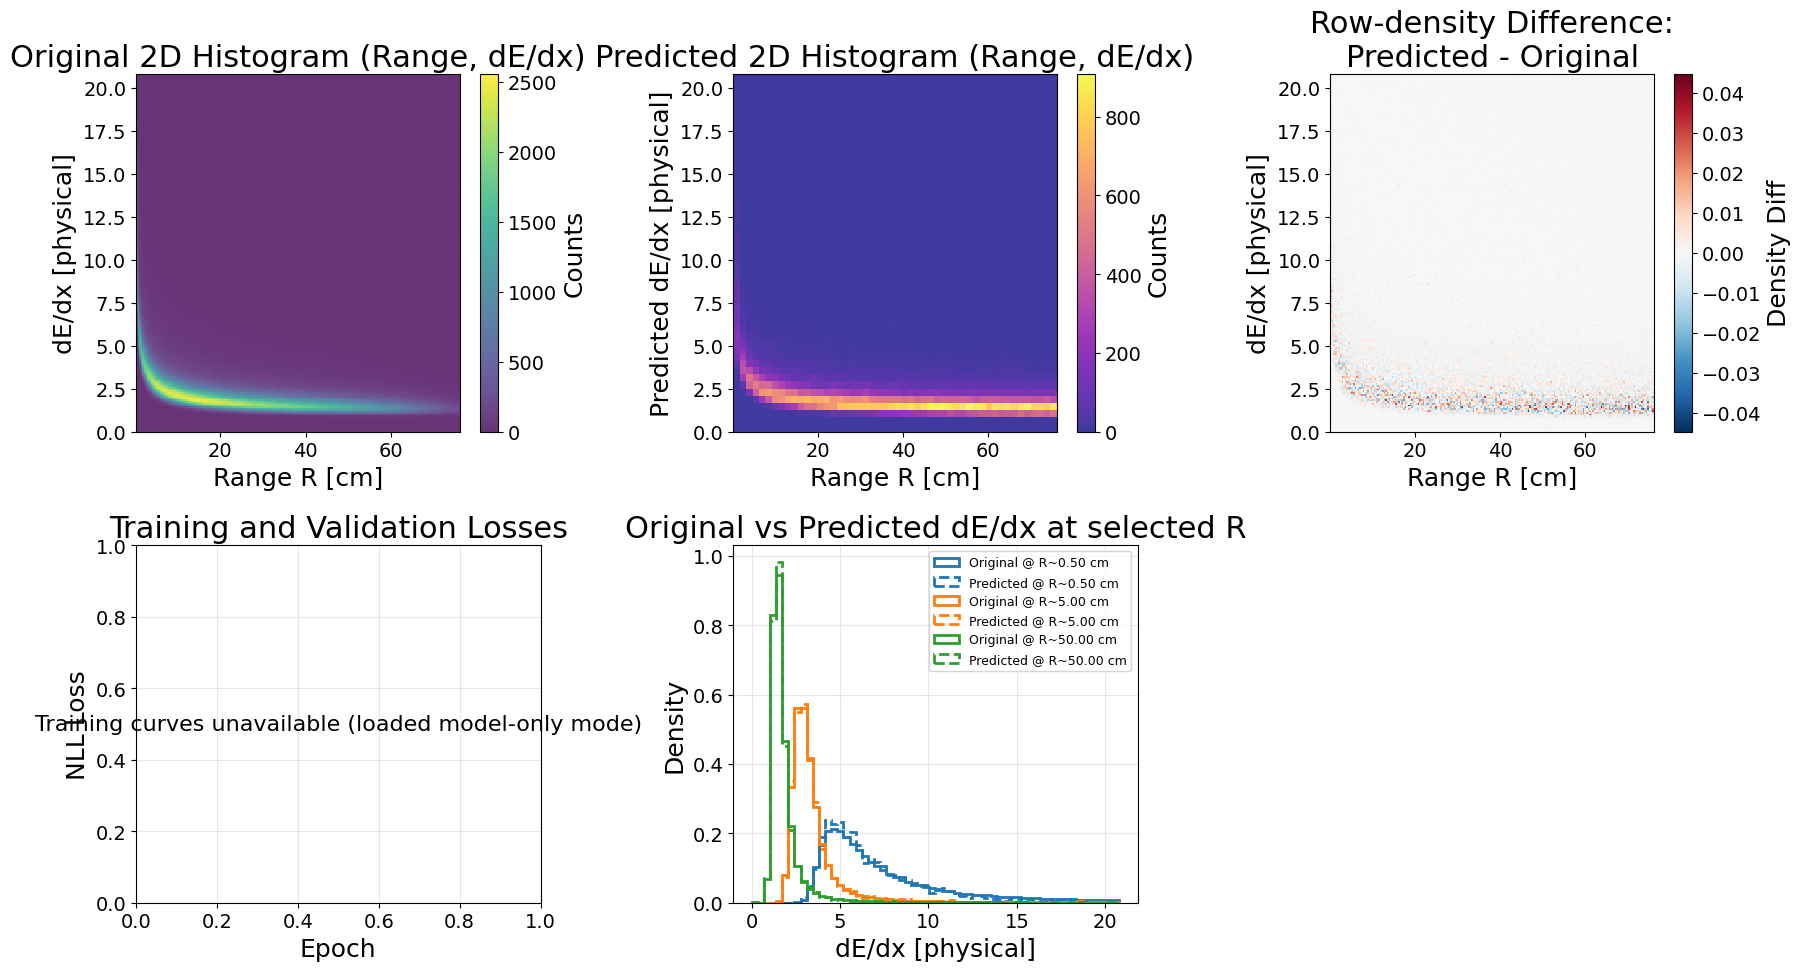

Visualization complete.


In [ ]:
import numpy as np
import pickle
from pathlib import Path
import equinox as eqx
import matplotlib.pyplot as plt

def _ensure_typed_key_local(key):
    if not hasattr(jax.random, "key"):
        return key
    try:
        if jax.dtypes.issubdtype(key.dtype, jax.dtypes.prng_key):
            return key
    except Exception:
        pass
    key_data = np.asarray(key, dtype=np.uint32).reshape(-1)
    if key_data.size >= 2:
        seed64 = (np.uint64(key_data[0]) << np.uint64(32)) ^ np.uint64(key_data[1])
    elif key_data.size == 1:
        seed64 = np.uint64(key_data[0])
    else:
        seed64 = np.uint64(0)
    seed = int(seed64 % np.uint64(np.iinfo(np.uint32).max))
    return jax.random.key(seed)

# Cell-local sampler to avoid stale global definitions from previous executions.
def _sample_conditional_cell22(condition_normalized, n_samples, params, key, flow=None, flow_type='flowjax'):
    key = _ensure_typed_key_local(key)
    conditions = jnp.asarray(condition_normalized, dtype=jnp.float32)

    if flow_type == 'flowjax':
        model_ref = params if hasattr(params, 'sample') else flow
        if model_ref is None:
            raise ValueError('No flow model available for sampling.')

        if flow_cond_dim_plot == 0:
            cond_empty = jnp.zeros((n_samples, 0), dtype=jnp.float32)
            samples = model_ref.sample(key, sample_shape=(), condition=cond_empty)
            return jnp.asarray(samples).reshape(-1)

        if conditions.ndim == 0:
            condition_1d = jnp.asarray([conditions], dtype=jnp.float32)
            samples = model_ref.sample(key, sample_shape=(n_samples,), condition=condition_1d)
            return jnp.asarray(samples).reshape(-1)

        conditions = conditions.reshape(-1)
        if int(conditions.shape[0]) != int(n_samples):
            raise ValueError(
                f"For batched conditions, n_samples must equal len(condition_normalized). "
                f"Got n_samples={n_samples}, len={int(conditions.shape[0])}."
            )
        condition_2d = conditions[:, None]
        samples = model_ref.sample(key, sample_shape=(), condition=condition_2d)
        return jnp.asarray(samples).reshape(-1)

    if conditions.ndim == 0:
        conditions = jnp.full((n_samples,), conditions, dtype=jnp.float32)
    else:
        conditions = conditions.reshape(-1)
        if int(conditions.shape[0]) != int(n_samples):
            raise ValueError(
                f"For batched conditions, n_samples must equal len(condition_normalized). "
                f"Got n_samples={n_samples}, len={int(conditions.shape[0])}."
            )
    keys = jax.random.split(key, n_samples)
    z_samples = jax.random.normal(key, (n_samples,), dtype=jnp.float32)
    return vmap(
        lambda z, c, k: affine_coupling_inverse(z, c, params, k)
    )(z_samples, conditions, keys)

# ---- Optional: plot with model loaded from stored files ----
PLOT_USE_STORED_FLOW = False
PLOT_STORED_MODEL_TAG = tag
PLOT_STORED_MODEL_DIR = Path('/sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties')

def _make_flow_template_for_load(cond_dim):
    return masked_autoregressive_flow(
        key=jax.random.PRNGKey(0),
        base_dist=StandardNormal((1,)),
        transformer=RationalQuadraticSpline(knots=8, interval=5.0),
        cond_dim=int(cond_dim),
        flow_layers=6,
        nn_width=64,
        nn_depth=3,
    )

plot_flow = globals().get('flow', None)
plot_params = globals().get('best_params', plot_flow)
plot_norm_params = dict(globals().get('norm_params', {}))
flow_type_plot = globals().get('flow_type', 'flowjax')
flow_cond_dim_plot = int(globals().get('flow_cond_dim', 1))

if PLOT_USE_STORED_FLOW:
    meta_path = PLOT_STORED_MODEL_DIR / f'dedx_flow_model_meta_{PLOT_STORED_MODEL_TAG}.pkl'
    with open(meta_path, 'rb') as f:
        model_meta = pickle.load(f)

    state_file = model_meta.get('model_state_file', f'dedx_flow_model_{PLOT_STORED_MODEL_TAG}.eqx')
    state_path = PLOT_STORED_MODEL_DIR / state_file

    flow_cond_dim_plot = int(model_meta.get('cond_dim', 0 if model_meta.get('condition_mode') == 'unconditional' else 1))
    flow_type_plot = model_meta.get('flow_type', 'flowjax')
    plot_norm_params = dict(model_meta.get('norm_params', {}))

    if flow_type_plot != 'flowjax':
        raise ValueError(f"Stored model plotting currently supports flowjax only. Found: {flow_type_plot}")

    flow_template = _make_flow_template_for_load(flow_cond_dim_plot)
    plot_flow = eqx.tree_deserialise_leaves(state_path, flow_template)
    plot_params = plot_flow
    print(f"Plotting with stored flow model: {state_path}")
else:
    print('Plotting with in-memory flow model (best_params/flow).')

if plot_params is None:
    meta_path = PLOT_STORED_MODEL_DIR / f'dedx_flow_model_meta_{PLOT_STORED_MODEL_TAG}.pkl'
    with open(meta_path, 'rb') as f:
        model_meta = pickle.load(f)
    state_file = model_meta.get('model_state_file', f'dedx_flow_model_{PLOT_STORED_MODEL_TAG}.eqx')
    state_path = PLOT_STORED_MODEL_DIR / state_file
    flow_cond_dim_plot = int(model_meta.get('cond_dim', 0 if model_meta.get('condition_mode') == 'unconditional' else 1))
    flow_type_plot = model_meta.get('flow_type', 'flowjax')
    plot_norm_params = dict(model_meta.get('norm_params', {}))
    flow_template = _make_flow_template_for_load(flow_cond_dim_plot)
    plot_flow = eqx.tree_deserialise_leaves(state_path, flow_template)
    plot_params = plot_flow
    print(f"In-memory model missing; auto-loaded stored flow model: {state_path}")

plot_R_mean = float(plot_norm_params.get('R_mean', globals().get('R_mean', 0.0)))
plot_R_std = float(plot_norm_params.get('R_std', globals().get('R_std', 1.0)))
if plot_R_std < 1e-12:
    plot_R_std = 1.0
plot_dEdx_mean = float(plot_norm_params.get('dEdx_log_mean', globals().get('dEdx_mean', 0.0)))
plot_dEdx_std = float(plot_norm_params.get('dEdx_log_std', globals().get('dEdx_std', 1.0)))
if plot_dEdx_std < 1e-12:
    plot_dEdx_std = 1.0
plot_dEdx_eps = float(plot_norm_params.get('dEdx_eps', 1e-8))

dedx_hi = float(np.percentile(dEdx_clean, 99.5))
if dedx_hi <= 0.0:
    dedx_hi = float(dEdx_clean.max())

if is_throughgoing_muon:
    # Through-going muon: compare 1D dE/dx only (R is not a valid conditioning variable).
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    n_pred_samples = 100000
    rng_key_pred = rng_key
    pred_dedx_phys_chunks = []
    batch_size = 1000
    n_total_generated = 0
    n_total_valid = 0

    for i in range(0, n_pred_samples, batch_size):
        n_batch = min(batch_size, n_pred_samples - i)
        rng_key_pred, subkey = jax.random.split(rng_key_pred)
        if flow_cond_dim_plot == 0:
            cond_batch = np.zeros((n_batch,), dtype=np.float32)
        else:
            # Defensive fallback: sample empirical R if a conditional model is loaded accidentally.
            r_lo, r_hi = np.percentile(R_clean, [0.5, 99.5])
            R_pred_phys = np.random.uniform(float(r_lo), float(r_hi), n_batch)
            cond_batch = ((R_pred_phys - plot_R_mean) / plot_R_std).astype(np.float32)

        samples_norm = _sample_conditional_cell22(
            cond_batch,
            n_batch,
            plot_params,
            subkey,
            flow=plot_flow,
            flow_type=flow_type_plot,
        )

        samples_norm = np.array(samples_norm, dtype=np.float32)
        samples_norm = np.nan_to_num(samples_norm, nan=0.0, posinf=10.0, neginf=-10.0)
        samples_log = samples_norm * plot_dEdx_std + plot_dEdx_mean
        # Prevent overflow when converting from log(dE/dx) back to physical units.
        samples_log = np.clip(samples_log, -20.0, 20.0)
        samples_phys = np.exp(samples_log) - plot_dEdx_eps
        samples_phys = np.clip(samples_phys, 0.0, None)

        valid = np.isfinite(samples_phys) & (samples_phys >= 0.0)
        n_total_generated += int(samples_phys.size)
        n_total_valid += int(np.count_nonzero(valid))
        if np.any(valid):
            pred_dedx_phys_chunks.append(samples_phys[valid])

    if len(pred_dedx_phys_chunks) == 0:
        print('Warning: no valid model predictions; plotting original distribution as fallback.')
        pred_dedx_phys = np.array(dEdx_clean, copy=True)
        n_total_valid = len(pred_dedx_phys)
        n_total_generated = len(pred_dedx_phys)
    else:
        pred_dedx_phys = np.concatenate(pred_dedx_phys_chunks)

    valid_frac = n_total_valid / max(n_total_generated, 1)
    print(f"Valid predicted samples: {n_total_valid}/{n_total_generated} ({valid_frac:.2%})")

    # Use a common plotting window based on both original and predicted distributions.
    combined = np.concatenate([dEdx_clean, pred_dedx_phys])
    dedx_hi_plot = float(np.percentile(combined, 99.5))
    if not np.isfinite(dedx_hi_plot) or dedx_hi_plot <= 0.0:
        dedx_hi_plot = max(float(np.max(dEdx_clean)), float(np.max(pred_dedx_phys)), 1.0)

    # 1) 1D histogram comparison
    ax = axes[0]
    ax.hist(
        dEdx_clean,
        bins=120,
        range=[0, dedx_hi_plot],
        density=True,
        histtype='step',
        linewidth=2.0,
        color='tab:blue',
        label='Original'
    )
    ax.hist(
        pred_dedx_phys,
        bins=120,
        range=[0, dedx_hi_plot],
        density=True,
        histtype='step',
        linewidth=2.0,
        color='tab:orange',
        label='Predicted'
    )
    ax.set_xlabel('dE/dx [physical]')
    ax.set_ylabel('Density')
    ax.set_title('Through-going Muon: 1D dE/dx')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 2) CDF comparison (count-normalized to avoid NaN from empty density bins).
    ax = axes[1]
    bins = np.linspace(0.0, dedx_hi_plot, 200)
    c_orig, edges = np.histogram(dEdx_clean, bins=bins, density=False)
    c_pred, _ = np.histogram(pred_dedx_phys, bins=bins, density=False)

    cdf_orig = np.cumsum(c_orig.astype(np.float64))
    cdf_pred = np.cumsum(c_pred.astype(np.float64))

    if cdf_orig[-1] > 0:
        cdf_orig /= cdf_orig[-1]
    if cdf_pred[-1] > 0:
        cdf_pred /= cdf_pred[-1]

    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.plot(centers, cdf_orig, label='Original CDF', color='tab:blue', linewidth=2.0)
    ax.plot(centers, cdf_pred, label='Predicted CDF', color='tab:orange', linewidth=2.0)
    ks = float(np.max(np.abs(cdf_orig - cdf_pred)))
    ax.set_xlabel('dE/dx [physical]')
    ax.set_ylabel('CDF')
    ax.set_title(f'CDF Comparison (KS={ks:.4f})')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 3) Training curves
    ax = axes[2]
    if 'train_losses' in globals() and 'val_losses' in globals() and len(train_losses) > 0 and len(val_losses) > 0:
        ax.plot(train_losses, label='Training Loss', alpha=0.7)
        ax.plot(val_losses, label='Validation Loss', alpha=0.7)
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'Training curves unavailable (loaded model-only mode)', ha='center', va='center', transform=ax.transAxes)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('NLL Loss')
    ax.set_title('Training and Validation Losses')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    # Stopping particles: keep 2D range-vs-dE/dx diagnostics.
    r_lo, r_hi = np.percentile(R_clean, [0.5, 99.5])
    if r_hi <= r_lo:
        r_lo, r_hi = float(R_clean.min()), float(R_clean.max())
    hist_range = [[float(r_lo), float(r_hi)], [0.0, float(dedx_hi)]]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Original 2D histogram in physical units
    ax = axes[0, 0]
    h0 = ax.hist2d(R_clean, dEdx_clean, bins=[200, 200], range=hist_range, cmap='viridis', alpha=0.8)
    ax.set_xlabel('Range R [cm]')
    ax.set_ylabel('dE/dx [physical]')
    ax.set_title('Original 2D Histogram (Range, dE/dx)')
    plt.colorbar(h0[3], ax=ax, label='Counts')
    h0_xedges = h0[1]
    h0_yedges = h0[2]

    # 2. 2D histogram of predicted (R, dE/dx) from the model
    ax = axes[0, 1]
    n_pred_samples = 100000
    R_pred_phys = np.random.uniform(r_lo, r_hi, n_pred_samples)
    R_pred_norm = (R_pred_phys - plot_R_mean) / plot_R_std
    rng_key_pred = rng_key
    pred_dedx_phys = []
    batch_size = 1000
    for i in range(0, n_pred_samples, batch_size):
        this_batch = R_pred_norm[i:i+batch_size]
        rng_key_pred, subkey = jax.random.split(rng_key_pred)
        samples_norm = _sample_conditional_cell22(this_batch, len(this_batch), plot_params, subkey, flow=plot_flow, flow_type=flow_type_plot)
        samples_log = np.array(samples_norm) * plot_dEdx_std + plot_dEdx_mean
        samples_phys = np.exp(samples_log) - plot_dEdx_eps
        samples_phys = np.clip(samples_phys, 0.0, None)
        pred_dedx_phys.append(samples_phys)
    pred_dedx_phys = np.concatenate(pred_dedx_phys)
    h1 = ax.hist2d(R_pred_phys, pred_dedx_phys, bins=50, range=hist_range, cmap='plasma', alpha=0.8)
    ax.set_xlabel('Range R [cm]')
    ax.set_ylabel('Predicted dE/dx [physical]')
    ax.set_title('Predicted 2D Histogram (Range, dE/dx)')
    plt.colorbar(h1[3], ax=ax, label='Counts')

    # 3. Row-normalized difference: predicted density - original density
    ax = axes[0, 2]
    h_orig_diff, _, _ = np.histogram2d(R_clean, dEdx_clean, bins=[h0_xedges, h0_yedges])
    h_pred_diff, _, _ = np.histogram2d(R_pred_phys, pred_dedx_phys, bins=[h0_xedges, h0_yedges])

    def normalize_rows_to_density(h):
        row_sum = h.sum(axis=1, keepdims=True)
        h_norm = np.divide(h, row_sum, out=np.zeros_like(h, dtype=float), where=row_sum > 0)
        return h_norm

    h_orig_row_density = normalize_rows_to_density(h_orig_diff)
    h_pred_row_density = normalize_rows_to_density(h_pred_diff)
    h_row_density_diff = h_pred_row_density - h_orig_row_density

    vmax = np.max(np.abs(h_row_density_diff))
    if vmax == 0:
        vmax = 1.0

    im = ax.pcolormesh(
        h0_xedges,
        h0_yedges,
        h_row_density_diff.T,
        cmap='RdBu_r',
        shading='auto',
        vmin=-vmax,
        vmax=vmax,
    )
    ax.set_xlabel('Range R [cm]')
    ax.set_ylabel('dE/dx [physical]')
    ax.set_title('Row-density Difference:\nPredicted - Original')
    plt.colorbar(im, ax=ax, label='Density Diff')

    # 4. Training and validation loss curves
    ax = axes[1, 0]
    if 'train_losses' in globals() and 'val_losses' in globals() and len(train_losses) > 0 and len(val_losses) > 0:
        ax.plot(train_losses, label='Training Loss', alpha=0.7)
        ax.plot(val_losses, label='Validation Loss', alpha=0.7)
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'Training curves unavailable (loaded model-only mode)', ha='center', va='center', transform=ax.transAxes)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('NLL Loss')
    ax.set_title('Training and Validation Losses')
    ax.grid(True, alpha=0.3)

    # 5. 1D dE/dx comparisons at selected R bins
    ax = axes[1, 1]
    R_targets = [0.5, 5.0, 50.0]
    R_half_width = max(0.25, 0.02 * float(R_clean.max() - R_clean.min()))
    colors = ['tab:blue', 'tab:orange', 'tab:green']

    for R_tgt, color in zip(R_targets, colors):
        r_lo_t, r_hi_t = R_tgt - R_half_width, R_tgt + R_half_width

        mask_orig = (R_clean >= r_lo_t) & (R_clean < r_hi_t)
        mask_pred = (R_pred_phys >= r_lo_t) & (R_pred_phys < r_hi_t)

        orig_slice = dEdx_clean[mask_orig]
        pred_slice = pred_dedx_phys[mask_pred]

        if len(orig_slice) > 10 and len(pred_slice) > 10:
            ax.hist(
                orig_slice,
                bins=60,
                range=[0, dedx_hi],
                density=True,
                histtype='step',
                linewidth=2.0,
                color=color,
                linestyle='-',
                label=f'Original @ R~{R_tgt:.2f} cm'
            )
            ax.hist(
                pred_slice,
                bins=60,
                range=[0, dedx_hi],
                density=True,
                histtype='step',
                linewidth=2.0,
                color=color,
                linestyle='--',
                label=f'Predicted @ R~{R_tgt:.2f} cm'
            )

    ax.set_xlabel('dE/dx [physical]')
    ax.set_ylabel('Density')
    ax.set_title('Original vs Predicted dE/dx at selected R')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Hide the extra subplot
    ax_empty = axes[1, 2]
    ax_empty.axis('off')

    plt.tight_layout()
    plt.show()

print("Visualization complete.")

Using stored flow model: /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/dedx_flow_model_stopping_proton_dx0.1mm.eqx
R used for prediction: 3653236 / 3653236
Saved per-segment flow prediction file: /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/flow_predictions/dedx_flow_pred_per_segment_stopping_proton.npz
Saved flow prediction artifact: /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/flow_predictions/dedx_flow_pred2d_stopping_proton.npz


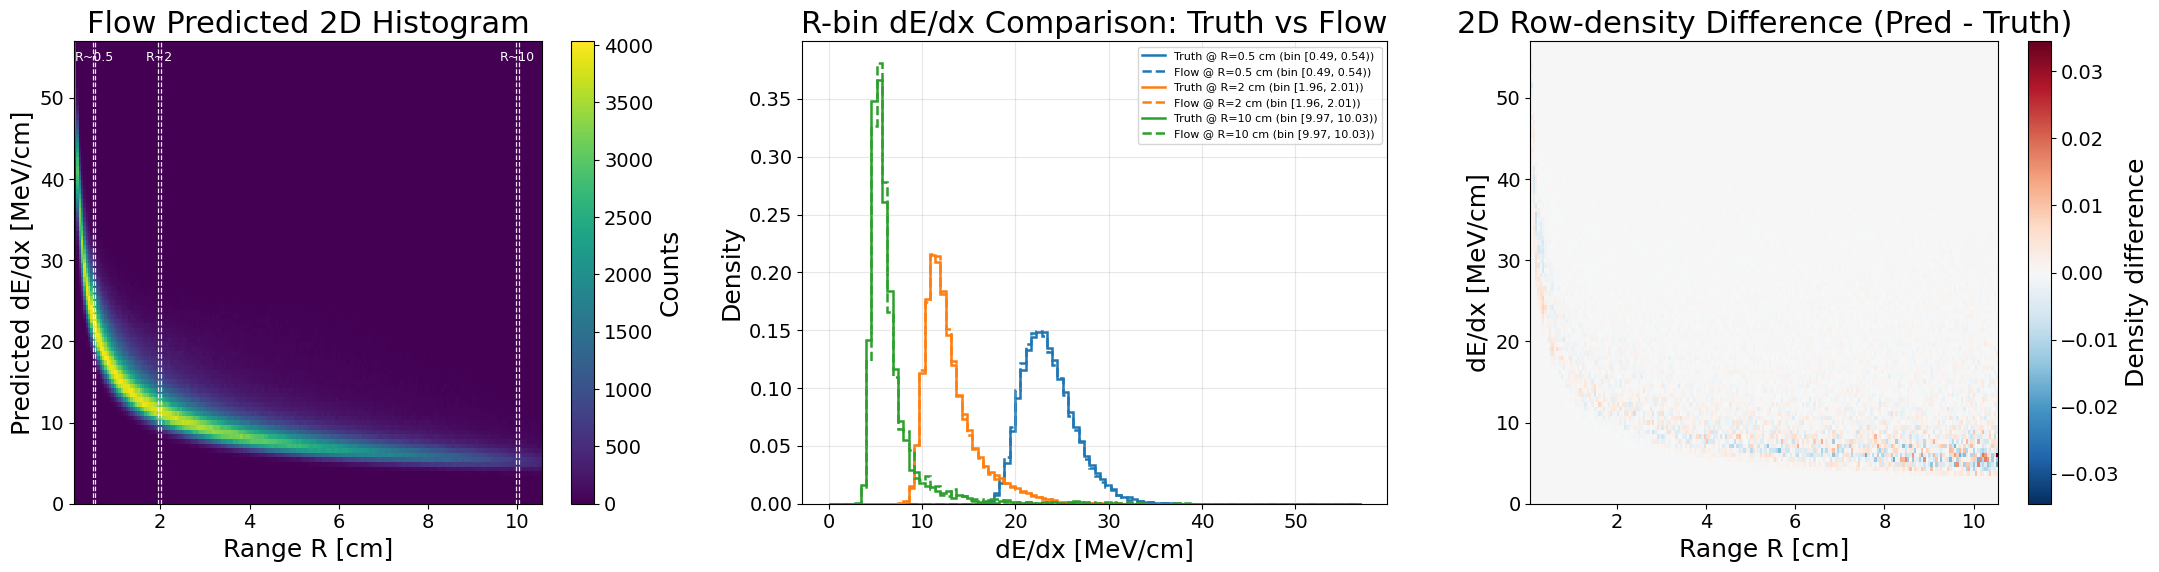

Cell 23 complete: R-bin comparison and 2D density difference plotted.


In [4]:
# Cell 23: Segment-wise R -> flow prediction map + projected-1D comparison + 2D density difference
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import equinox as eqx

# -------------------------
# User controls
# -------------------------
PRED_USE_STORED_FLOW = True
PRED_STORED_MODEL_TAG = tag
PRED_STORED_MODEL_DIR = Path('/sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties')

# Set to None to use all segment R values from the selected file.
# Keep an integer cap for faster interactive plotting.
PRED_MAX_SEGMENTS = None  # use None for all segments
PRED_BATCH_SIZE = 10000
PRED_SLICE_R_TARGETS = [0.5, 2.0, 10.0]
# PRED_SLICE_R_TARGETS = [0.5, 2.0, 20.0]

# Number of bins used if histogram artifacts are not available in memory.
PRED_FALLBACK_R_BINS = 200
PRED_FALLBACK_DEDX_BINS = 100


def _ensure_typed_key_local_pred(key):
    if not hasattr(jax.random, 'key'):
        return key
    try:
        if jax.dtypes.issubdtype(key.dtype, jax.dtypes.prng_key):
            return key
    except Exception:
        pass
    key_data = np.asarray(key, dtype=np.uint32).reshape(-1)
    if key_data.size >= 2:
        seed64 = (np.uint64(key_data[0]) << np.uint64(32)) ^ np.uint64(key_data[1])
    elif key_data.size == 1:
        seed64 = np.uint64(key_data[0])
    else:
        seed64 = np.uint64(0)
    seed = int(seed64 % np.uint64(np.iinfo(np.uint32).max))
    return jax.random.key(seed)


def _make_flow_template_for_load_pred(cond_dim):
    return masked_autoregressive_flow(
        key=jax.random.PRNGKey(0),
        base_dist=StandardNormal((1,)),
        transformer=RationalQuadraticSpline(knots=8, interval=5.0),
        cond_dim=int(cond_dim),
        flow_layers=6,
        nn_width=64,
        nn_depth=3,
    )


def _sample_conditional_for_pred(cond_values_norm, model_ref, cond_dim, flow_type, key):
    key = _ensure_typed_key_local_pred(key)
    cond_values_norm = np.asarray(cond_values_norm, dtype=np.float32)
    n_samples = int(cond_values_norm.shape[0])

    if flow_type != 'flowjax':
        raise ValueError(f'Only flowjax sampling is supported here, got {flow_type}.')

    if cond_dim == 0:
        cond_arr = jnp.zeros((n_samples, 0), dtype=jnp.float32)
        y_norm = model_ref.sample(key, sample_shape=(), condition=cond_arr)
    else:
        cond_arr = jnp.asarray(cond_values_norm[:, None], dtype=jnp.float32)
        y_norm = model_ref.sample(key, sample_shape=(), condition=cond_arr)

    return np.asarray(y_norm, dtype=np.float32).reshape(-1)


# -------------------------
# Load model + normalization
# -------------------------
if PRED_USE_STORED_FLOW:
    meta_path = PRED_STORED_MODEL_DIR / f'dedx_flow_model_meta_{PRED_STORED_MODEL_TAG}.pkl'
    with open(meta_path, 'rb') as f:
        model_meta = pickle.load(f)

    state_file = model_meta.get('model_state_file', f'dedx_flow_model_{PRED_STORED_MODEL_TAG}.eqx')
    state_path = PRED_STORED_MODEL_DIR / state_file

    pred_cond_dim = int(model_meta.get('cond_dim', 0 if model_meta.get('condition_mode') == 'unconditional' else 1))
    pred_flow_type = model_meta.get('flow_type', 'flowjax')
    pred_norm = dict(model_meta.get('norm_params', {}))

    flow_template = _make_flow_template_for_load_pred(pred_cond_dim)
    pred_flow_model = eqx.tree_deserialise_leaves(state_path, flow_template)
    print(f'Using stored flow model: {state_path}')
else:
    pred_flow_model = globals().get('best_params', globals().get('flow', None))
    pred_cond_dim = int(globals().get('flow_cond_dim', 1))
    pred_flow_type = globals().get('flow_type', 'flowjax')
    pred_norm = dict(globals().get('norm_params', {}))
    if pred_flow_model is None:
        raise ValueError('No in-memory flow model found. Run training or set PRED_USE_STORED_FLOW=True.')
    print('Using in-memory flow model.')

pred_R_mean = float(pred_norm.get('R_mean', globals().get('R_mean', 0.0)))
pred_R_std = float(pred_norm.get('R_std', globals().get('R_std', 1.0)))
if pred_R_std < 1e-12:
    pred_R_std = 1.0
pred_dlog_mean = float(pred_norm.get('dEdx_log_mean', globals().get('dEdx_mean', 0.0)))
pred_dlog_std = float(pred_norm.get('dEdx_log_std', globals().get('dEdx_std', 1.0)))
if pred_dlog_std < 1e-12:
    pred_dlog_std = 1.0
pred_eps = float(pred_norm.get('dEdx_eps', 1e-8))


# -------------------------
# Prediction artifact paths
# -------------------------
particle_type_key = str(PRED_STORED_MODEL_TAG).split('_dx')[0]
pred_out_dir = PRED_STORED_MODEL_DIR / 'flow_predictions'
pred_out_dir.mkdir(parents=True, exist_ok=True)
pred_out_path = pred_out_dir / f'dedx_flow_pred2d_{particle_type_key}.npz'
pred_seg_out_path = pred_out_dir / f'dedx_flow_pred_per_segment_{particle_type_key}.npz'


# -------------------------
# Use per-segment R from file (or cached prediction)
# -------------------------
loaded_cached_prediction = False
if pred_seg_out_path.exists():
    with np.load(pred_seg_out_path) as cached_pred:
        if 'R_segments' in cached_pred.files and 'flow_dedx_pred' in cached_pred.files:
            R_segments_cached = np.asarray(cached_pred['R_segments'], dtype=np.float32)
            flow_dedx_cached = np.asarray(cached_pred['flow_dedx_pred'], dtype=np.float32)
            if R_segments_cached.size > 0 and R_segments_cached.size == flow_dedx_cached.size:
                R_segments_pred = R_segments_cached
                flow_dedx_pred = flow_dedx_cached
                loaded_cached_prediction = True

if loaded_cached_prediction:
    print(f'Loaded per-segment flow prediction: {pred_seg_out_path}')
    print('Skipping flow sampling and jumping to drawing.')
else:
    if is_throughgoing_muon:
        seg_mask = np.isfinite(range_data)
    else:
        seg_mask = np.isfinite(range_data) & (range_data > 0)

    R_segments_all = np.asarray(range_data[seg_mask], dtype=np.float32)
    if R_segments_all.size == 0:
        raise ValueError('No valid segment R values available for prediction.')

    if PRED_MAX_SEGMENTS is not None and R_segments_all.size > int(PRED_MAX_SEGMENTS):
        # Deterministic down-sampling for interactive plotting speed.
        idx = np.linspace(0, R_segments_all.size - 1, int(PRED_MAX_SEGMENTS), dtype=np.int64)
        R_segments_pred = R_segments_all[idx]
    else:
        R_segments_pred = R_segments_all

    print(f'R used for prediction: {R_segments_pred.size} / {R_segments_all.size}')

    # Predict one dE/dx sample per segment-R
    rng_pred = _ensure_typed_key_local_pred(globals().get('rng_key', jax.random.PRNGKey(0)))
    flow_pred_chunks = []
    for start in range(0, R_segments_pred.size, int(PRED_BATCH_SIZE)):
        stop = min(start + int(PRED_BATCH_SIZE), R_segments_pred.size)
        r_batch = R_segments_pred[start:stop]

        if pred_cond_dim == 0:
            cond_batch_norm = np.zeros_like(r_batch, dtype=np.float32)
        else:
            cond_batch_norm = ((r_batch - pred_R_mean) / pred_R_std).astype(np.float32)

        rng_pred, subkey = jax.random.split(rng_pred)
        y_norm_batch = _sample_conditional_for_pred(cond_batch_norm, pred_flow_model, pred_cond_dim, pred_flow_type, subkey)

        y_log_batch = y_norm_batch * pred_dlog_std + pred_dlog_mean
        y_log_batch = np.clip(y_log_batch, -20.0, 20.0)
        y_phys_batch = np.exp(y_log_batch) - pred_eps
        y_phys_batch = np.clip(y_phys_batch, 0.0, None)
        flow_pred_chunks.append(y_phys_batch)

    flow_dedx_pred = np.concatenate(flow_pred_chunks)

    # Save explicit per-segment prediction file for downstream reuse.
    np.savez(
        pred_seg_out_path,
        tag=np.asarray(str(PRED_STORED_MODEL_TAG)),
        particle_type=np.asarray(particle_type_key),
        R_segments=R_segments_pred.astype(np.float32),
        flow_dedx_pred=flow_dedx_pred.astype(np.float32),
    )
    print(f'Saved per-segment flow prediction file: {pred_seg_out_path}')


# -------------------------
# Build common-bin 2D histograms (truth vs prediction)
# -------------------------
if 'r_edges' in globals() and 'dedx_edges' in globals():
    r_edges_local = np.asarray(r_edges, dtype=np.float64)
    dedx_edges_local = np.asarray(dedx_edges, dtype=np.float64)
else:
    r_lo_h, r_hi_h = np.percentile(R_clean, [0.5, 99.5])
    d_lo_h, d_hi_h = 0.0, float(np.percentile(dEdx_clean, 99.5))
    r_edges_local = np.linspace(float(r_lo_h), float(r_hi_h), int(PRED_FALLBACK_R_BINS) + 1)
    dedx_edges_local = np.linspace(float(d_lo_h), float(d_hi_h), int(PRED_FALLBACK_DEDX_BINS) + 1)

# Truth and prediction on the same bin edges.
h_true_counts, _, _ = np.histogram2d(
    R_clean,
    dEdx_clean,
    bins=[r_edges_local, dedx_edges_local],
)
h_pred_counts, _, _ = np.histogram2d(
    R_segments_pred,
    flow_dedx_pred,
    bins=[r_edges_local, dedx_edges_local],
)


def _row_density(h2d):
    row_sum = h2d.sum(axis=1, keepdims=True)
    return np.divide(h2d, row_sum, out=np.zeros_like(h2d, dtype=np.float64), where=row_sum > 0)


h_true_density_row = _row_density(h_true_counts)
h_pred_density_row = _row_density(h_pred_counts)
h_density_diff_row = h_pred_density_row - h_true_density_row


# -------------------------
# 1D projected dE/dx comparison from built 2D histograms
# -------------------------
dedx_widths = np.diff(dedx_edges_local)

true_proj_counts = np.asarray(h_true_counts.sum(axis=0), dtype=np.float64)
pred_proj_counts = np.asarray(h_pred_counts.sum(axis=0), dtype=np.float64)

true_proj_prob = true_proj_counts / max(true_proj_counts.sum(), 1.0)
pred_proj_prob = pred_proj_counts / max(pred_proj_counts.sum(), 1.0)

true_proj_density = true_proj_prob / np.maximum(dedx_widths, 1e-12)
pred_proj_density = pred_proj_prob / np.maximum(dedx_widths, 1e-12)


# -------------------------
# Save 2D prediction artifact by particle type
# -------------------------
np.savez(
    pred_out_path,
    tag=np.asarray(str(PRED_STORED_MODEL_TAG)),
    particle_type=np.asarray(particle_type_key),
    r_edges=r_edges_local.astype(np.float32),
    dedx_edges=dedx_edges_local.astype(np.float32),
    h_pred_counts=h_pred_counts.astype(np.float32),
    h_true_counts=h_true_counts.astype(np.float32),
    h_pred_density_row=h_pred_density_row.astype(np.float32),
    h_true_density_row=h_true_density_row.astype(np.float32),
    h_density_diff_row=h_density_diff_row.astype(np.float32),
    pred_proj_density=pred_proj_density.astype(np.float32),
    true_proj_density=true_proj_density.astype(np.float32),
    R_segments_pred=R_segments_pred.astype(np.float32),
    flow_dedx_pred=flow_dedx_pred.astype(np.float32),
)
print(f'Saved flow prediction artifact: {pred_out_path}')


# -------------------------
# Plot: predicted 2D + R-slice comparison + 2D density diff
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Left: predicted 2D counts
ax = axes[0]
mesh0 = ax.pcolormesh(
    r_edges_local,
    dedx_edges_local,
    h_pred_counts.T,
    shading='auto',
    cmap='viridis',
)
ax.set_xlabel('Range R [cm]')
ax.set_ylabel('Predicted dE/dx [MeV/cm]')
ax.set_title('Flow Predicted 2D Histogram')
plt.colorbar(mesh0, ax=ax, label='Counts')

# Mark selected R bins with white dashed lines and labels.
for r_tgt in PRED_SLICE_R_TARGETS:
    ridx = np.searchsorted(r_edges_local, float(r_tgt), side='right') - 1
    ridx = int(np.clip(ridx, 0, len(r_edges_local) - 2))
    r_left = float(r_edges_local[ridx])
    r_right = float(r_edges_local[ridx + 1])
    ax.axvline(r_left, color='w', linestyle='--', linewidth=0.9, alpha=0.9)
    ax.axvline(r_right, color='w', linestyle='--', linewidth=0.9, alpha=0.9)
    ax.text(
        0.5 * (r_left + r_right),
        float(dedx_edges_local[-1]) * 0.98,
        f'R~{r_tgt:g}',
        color='w',
        fontsize=9,
        ha='center',
        va='top',
    )

# Middle: dE/dx density comparison at selected R bins
ax = axes[1]
colors = ['tab:blue', 'tab:orange', 'tab:green']
for r_tgt, color in zip(PRED_SLICE_R_TARGETS, colors):
    ridx = np.searchsorted(r_edges_local, float(r_tgt), side='right') - 1
    ridx = int(np.clip(ridx, 0, len(r_edges_local) - 2))

    true_slice_density = h_true_density_row[ridx, :] / np.maximum(dedx_widths, 1e-12)
    pred_slice_density = h_pred_density_row[ridx, :] / np.maximum(dedx_widths, 1e-12)

    r_left = float(r_edges_local[ridx])
    r_right = float(r_edges_local[ridx + 1])

    ax.stairs(
        true_slice_density,
        dedx_edges_local,
        linewidth=1.8,
        color=color,
        linestyle='-',
        label=f'Truth @ R={r_tgt:g} cm (bin [{r_left:.2f}, {r_right:.2f}))',
    )
    ax.stairs(
        pred_slice_density,
        dedx_edges_local,
        linewidth=1.8,
        color=color,
        linestyle='--',
        label=f'Flow @ R={r_tgt:g} cm (bin [{r_left:.2f}, {r_right:.2f}))',
    )

ax.set_xlabel('dE/dx [MeV/cm]')
ax.set_ylabel('Density')
ax.set_title('R-bin dE/dx Comparison: Truth vs Flow')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# Right: 2D row-density difference (pred - truth)
ax = axes[2]
vmax = float(np.max(np.abs(h_density_diff_row)))
if vmax <= 0.0:
    vmax = 1.0
mesh1 = ax.pcolormesh(
    r_edges_local,
    dedx_edges_local,
    h_density_diff_row.T,
    shading='auto',
    cmap='RdBu_r',
    vmin=-vmax,
    vmax=vmax,
)
ax.set_xlabel('Range R [cm]')
ax.set_ylabel('dE/dx [MeV/cm]')
ax.set_title('2D Row-density Difference (Pred - Truth)')
plt.colorbar(mesh1, ax=ax, label='Density difference')

plt.tight_layout()
plt.show()

print('Cell 23 complete: R-bin comparison and 2D density difference plotted.')

In [ ]:
# Save the trained model for use in quenching_jax.py
import pickle
from pathlib import Path
import numpy as np
import equinox as eqx

# Create output directory if it doesn't exist
model_dir = Path("/sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties")
model_dir.mkdir(exist_ok=True)

# Use Equinox leaf serialization for FlowJAX/Equinox models (pickle alone fails)
model_state_path = model_dir / f"dedx_flow_model_{tag}.eqx"
model_meta_path = model_dir / f"dedx_flow_model_meta_{tag}.pkl"
norm_params_path = model_dir / f"dedx_norm_params_{tag}.pkl"

# Serialize model leaves
eqx.tree_serialise_leaves(model_state_path, best_params)

# Store lightweight metadata separately
norm_params_serializable = {
    k: float(v) if isinstance(v, (np.floating, float, int)) else v
    for k, v in norm_params.items()
}

# Keep compatibility keys for unconditional models as a convenience.
if flow_cond_dim == 0:
    norm_params_serializable.setdefault("R_mean", 0.0)
    norm_params_serializable.setdefault("R_std", 1.0)

model_meta = {
    "flow_type": flow_type,
    "model_state_file": model_state_path.name,
    "norm_params": norm_params_serializable,
    "condition_mode": flow_condition_mode,
    "cond_dim": int(flow_cond_dim),
    "load_note": (
        "Rebuild a template flow with the same architecture, then call "
        "eqx.tree_deserialise_leaves(model_state_path, template_flow)."
    ),
}

with open(model_meta_path, "wb") as f:
    pickle.dump(model_meta, f)

# Optional standalone norm params file for compatibility with older scripts
with open(norm_params_path, "wb") as f:
    pickle.dump(norm_params_serializable, f)

print(f"Model state saved to {model_state_path}")
print(f"Model metadata saved to {model_meta_path}")
print(f"Normalization parameters saved to {norm_params_path}")
print(f"Model type: {flow_type}")
print(f"Flow condition mode: {flow_condition_mode} (cond_dim={flow_cond_dim})")
print("Normalization stats:")
print(f"  R: mean={norm_params_serializable['R_mean']:.4f}, std={norm_params_serializable['R_std']:.4f}")
print(
    f"  log(dEdx): mean={norm_params_serializable['dEdx_log_mean']:.4f}, "
    f"std={norm_params_serializable['dEdx_log_std']:.4f}"
)

Model state saved to /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/dedx_flow_model_throughgoing_muon_dx0.1mm.eqx
Model metadata saved to /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/dedx_flow_model_meta_throughgoing_muon_dx0.1mm.pkl
Normalization parameters saved to /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/dedx_norm_params_throughgoing_muon_dx0.1mm.pkl
Model type: flowjax
Flow condition mode: unconditional (cond_dim=0)
Normalization stats:
  R: mean=-23.5362, std=18.8863
  log(dEdx): mean=0.4886, std=0.4258


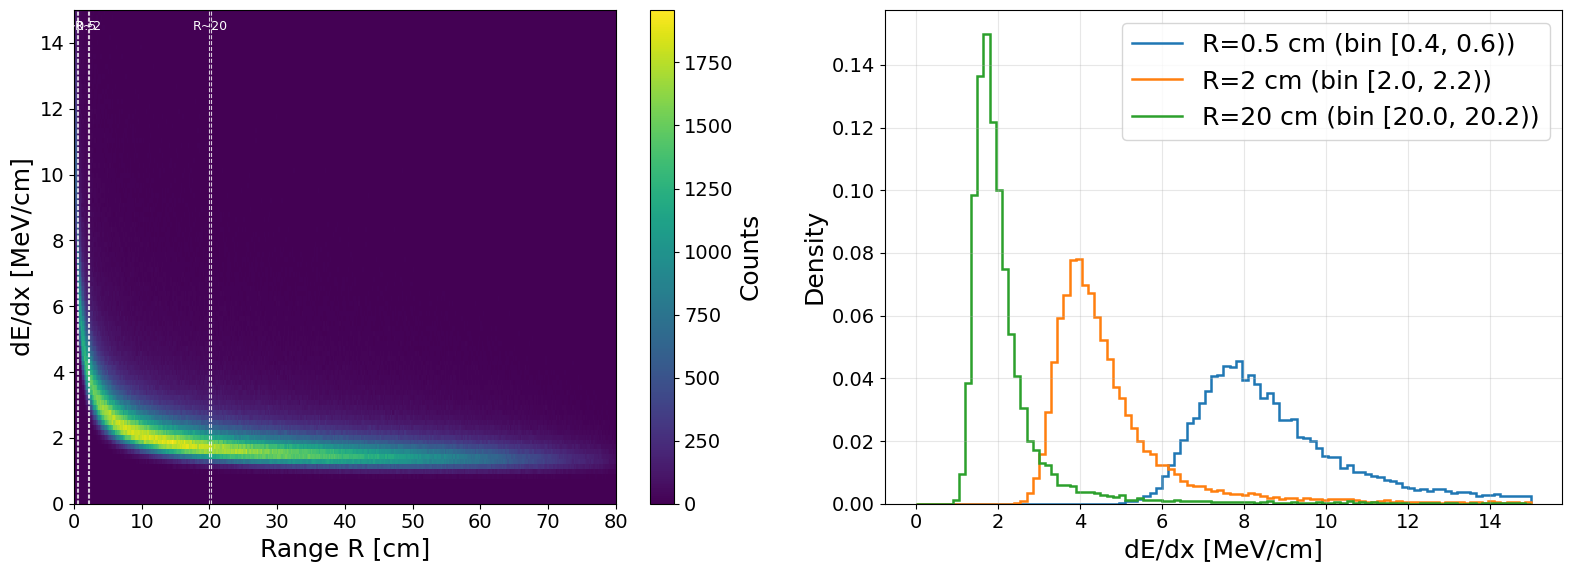

Saved 2D dE/dx histogram to /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/dedx_hist2d_stopping_muon_dx0.1mm_rbin400_dedxbin100.npz
counts shape=(400, 100), r_bins=400, dedx_bins=100
  slice R=0.5 cm -> bin 2, interval [0.400000, 0.600000)
  slice R=2 cm -> bin 10, interval [2.000000, 2.200000)
  slice R=20 cm -> bin 100, interval [20.000000, 20.200000)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Build 2D histogram directly (same binning/range as before)
r_bins = 400 #4000
dedx_bins = 100 #10 #100

# #stopping proton
# r_range = (0.0, 20.0)
# dedx_range = (0.0, 60.0)

# stopping muon
r_range = (0.0, 80.0)
dedx_range = (0.0, 15.0)

# r_range = (0.0, 80.0)
# dedx_range = (0.0, 10.0)

h_counts, r_edges, dedx_edges = np.histogram2d(
    R_clean,
    dEdx_clean,
    bins=[r_bins, dedx_bins],
    range=[r_range, dedx_range],
)

# Prepare centers for slice plotting
dedx_centers = 0.5 * (dedx_edges[:-1] + dedx_edges[1:])

# Target R values and corresponding histogram row indices
slice_targets = np.array([0.5, 2.0, 20.0], dtype=np.float32)
# slice_targets = np.array([0.5, 5.0, 50.0], dtype=np.float32)
slice_bin_indices = np.clip(
    np.searchsorted(r_edges, slice_targets, side="right") - 1,
    0,
    len(r_edges) - 2,
)

# Figure with 2 panels: 2D histogram + row slices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: 2D histogram
ax0 = axes[0]
mesh = ax0.pcolormesh(
    r_edges,
    dedx_edges,
    h_counts.T,
    shading="auto",
    cmap="viridis",
)
ax0.set_xlabel("Range R [cm]")
ax0.set_ylabel("dE/dx [MeV/cm]")
# ax0.set_title("Original 2D Histogram (Range, dE/dx)")
plt.colorbar(mesh, ax=ax0, label="Counts")

# Mark selected R bins on the 2D panel
for t, idx in zip(slice_targets, slice_bin_indices):
    r_left = r_edges[idx]
    r_right = r_edges[idx + 1]
    ax0.axvline(r_left, color="w", linestyle="--", linewidth=0.8, alpha=0.8)
    ax0.axvline(r_right, color="w", linestyle="--", linewidth=0.8, alpha=0.8)
    ax0.text(
        0.5 * (r_left + r_right),
        dedx_range[1] * 0.98,
        f"R~{t:g}",
        color="w",
        fontsize=9,
        ha="center",
        va="top",
    )

# Right: dE/dx slices at corresponding R bins (row-normalized histograms)
ax1 = axes[1]
slice_rows_density = []
for t, idx in zip(slice_targets, slice_bin_indices):
    row_counts = h_counts[idx, :]
    row_sum = row_counts.sum()
    if row_sum > 0:
        row_density = row_counts / row_sum
    else:
        row_density = np.zeros_like(row_counts)

    slice_rows_density.append(row_density.astype(np.float32))

    r_left = r_edges[idx]
    r_right = r_edges[idx + 1]
    ax1.stairs(
        row_density,
        dedx_edges,
        linewidth=1.8,
        label=f"R={t:g} cm (bin [{r_left:.1f}, {r_right:.1f}))",
    )

ax1.set_xlabel("dE/dx [MeV/cm]")
ax1.set_ylabel("Density")
# ax1.set_title("dE/dx Hist Slices at Corresponding R Bins")
ax1.grid(alpha=0.3)
ax1.legend()

plt.tight_layout()
plt.show()

# Persist histogram artifact for quenching_jax.py lookup-based dE/dx density.
hist_dir = Path("/sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties")
hist_dir.mkdir(exist_ok=True)
hist_path = hist_dir / f"dedx_hist2d_{tag}_rbin{r_bins}_dedxbin{dedx_bins}.npz"

np.savez(
    hist_path,
    counts=h_counts.astype(np.float32),
    r_edges=r_edges.astype(np.float32),
    dedx_edges=dedx_edges.astype(np.float32),
    slice_targets_cm=slice_targets.astype(np.float32),
    slice_bin_indices=slice_bin_indices.astype(np.int32),
    slice_rows_density=np.asarray(slice_rows_density, dtype=np.float32),
)

print(f"Saved 2D dE/dx histogram to {hist_path}")
print(f"counts shape={h_counts.shape}, r_bins={len(r_edges)-1}, dedx_bins={len(dedx_edges)-1}")
for t, idx in zip(slice_targets, slice_bin_indices):
    print(f"  slice R={t:g} cm -> bin {idx}, interval [{r_edges[idx]:.6f}, {r_edges[idx+1]:.6f})")

Saved 1D marginal dE/dx histogram to /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/dedx_hist1d_throughgoing_muon_dx0.1mm.npz
counts shape=(100,), dedx_bins=100
Total counts: 32930834.0


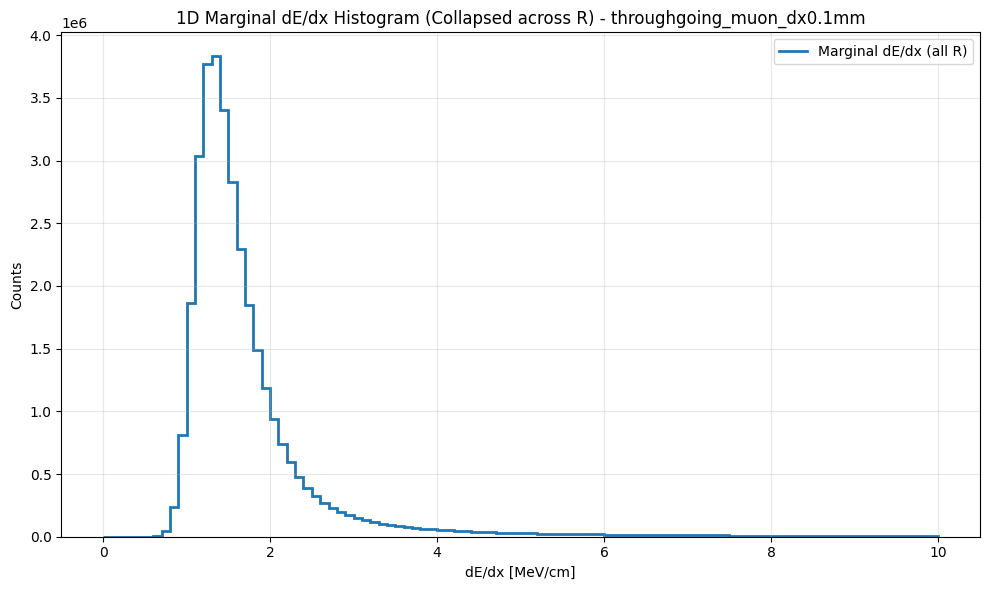

1D histogram storage complete.


In [ ]:
import numpy as np
from pathlib import Path

# Compute 1D marginal dE/dx histogram (collapsed across all R)
# Use the same dedx_edges from the 2D histogram for consistency
dedx_1d_counts = h_counts.sum(axis=0)  # Sum over all R bins

# Prepare output directory
hist_dir = Path("/sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties")
hist_dir.mkdir(exist_ok=True)

# Save 1D marginal dE/dx histogram as separate artifact
hist_1d_path = hist_dir / f"dedx_hist1d_{tag}.npz"

np.savez(
    hist_1d_path,
    counts=dedx_1d_counts.astype(np.float32),
    dedx_edges=dedx_edges.astype(np.float32),
)

print(f"Saved 1D marginal dE/dx histogram to {hist_1d_path}")
print(f"counts shape={dedx_1d_counts.shape}, dedx_bins={len(dedx_edges)-1}")
print(f"Total counts: {dedx_1d_counts.sum()}")

# Also plot the 1D marginal for visual reference
fig, ax = plt.subplots(figsize=(10, 6))
ax.stairs(
    dedx_1d_counts,
    dedx_edges,
    linewidth=2.0,
    color="tab:blue",
    label="Marginal dE/dx (all R)",
)
ax.set_xlabel("dE/dx [MeV/cm]")
ax.set_ylabel("Counts")
ax.set_title(f"1D Marginal dE/dx Histogram (Collapsed across R) - {tag}")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("1D histogram storage complete.")


NPZ counts shape: (4000, 100), total=37092440
H5 counts shape:  (4000, 100), total=3642451
Input segments in H5: 3653236


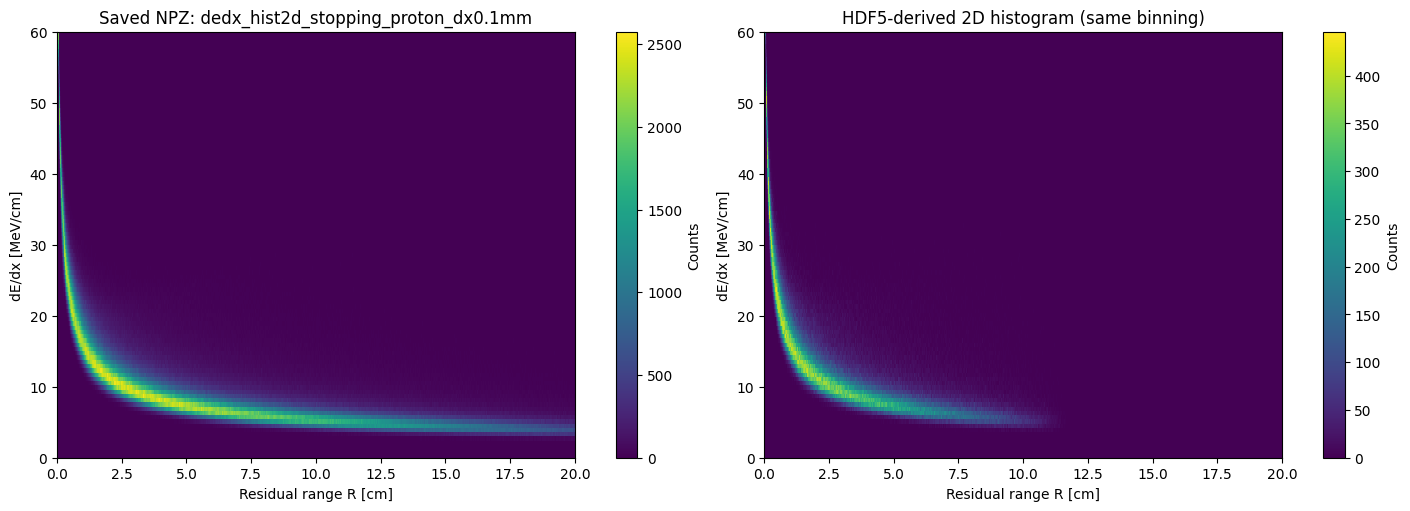

In [ ]:
# Debug plot: compare saved stopping-proton histogram artifact vs source HDF5 segments side by side.
import numpy as np
import h5py
import matplotlib.pyplot as plt

npz_path = "/sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/dedx_hist2d_stopping_proton_dx0.1mm.npz"
h5_path = "/sdf/data/neutrino/cyifan/dunend_train_prod/prod_mod0_mpvmpr/production_3557923/job_23705529_0000/output_23705529_0000-edepsim_lbl_range_0.05cm.h5"

# Load saved histogram artifact.
artifact = np.load(npz_path)
artifact_counts = np.asarray(artifact["counts"], dtype=np.float32)
r_edges = np.asarray(artifact["r_edges"], dtype=np.float32)
dedx_key = "dedx_edges" if "dedx_edges" in artifact.files else "dedex_edges"
dedx_edges = np.asarray(artifact[dedx_key], dtype=np.float32)

# Load raw HDF5 segments and make a histogram with exactly the same bin edges.
with h5py.File(h5_path, "r") as f:
    seg = f["segments"][:]
range_h5 = np.asarray(seg["range"], dtype=np.float32)
dedx_h5 = np.asarray(seg["dEdx"], dtype=np.float32)

h5_counts, _, _ = np.histogram2d(range_h5, dedx_h5, bins=[r_edges, dedx_edges])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

m0 = axes[0].pcolormesh(r_edges, dedx_edges, artifact_counts.T, shading="auto", cmap="viridis")
axes[0].set_title("Saved NPZ: dedx_hist2d_stopping_proton_dx0.1mm")
axes[0].set_xlabel("Residual range R [cm]")
axes[0].set_ylabel("dE/dx [MeV/cm]")
plt.colorbar(m0, ax=axes[0], label="Counts")

m1 = axes[1].pcolormesh(r_edges, dedx_edges, h5_counts.T, shading="auto", cmap="viridis")
axes[1].set_title("HDF5-derived 2D histogram (same binning)")
axes[1].set_xlabel("Residual range R [cm]")
axes[1].set_ylabel("dE/dx [MeV/cm]")
plt.colorbar(m1, ax=axes[1], label="Counts")

print(f"NPZ counts shape: {artifact_counts.shape}, total={artifact_counts.sum():.0f}")
print(f"H5 counts shape:  {h5_counts.shape}, total={h5_counts.sum():.0f}")
print(f"Input segments in H5: {len(range_h5)}")

plt.show()

Max absolute density difference: 9.898263e-01


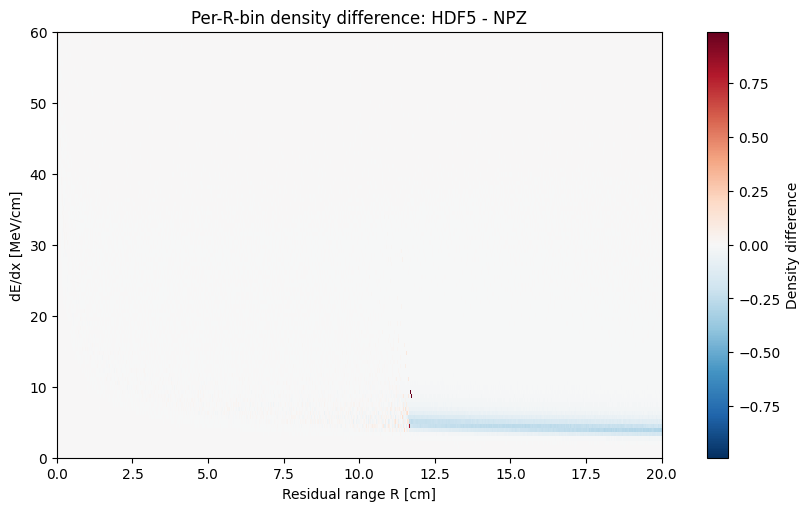

In [ ]:
# Row-normalized (per-R-bin) density difference: HDF5-derived minus saved NPZ histogram.
import numpy as np
import matplotlib.pyplot as plt

# Reuse arrays from the previous debug cell if present; otherwise load them here.
try:
    artifact_counts
    h5_counts
    r_edges
    dedx_edges
except NameError:
    npz_path = "/sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/src/larndsim/detector_properties/dedx_hist2d_stopping_proton_dx0.1mm.npz"
    h5_path = "/sdf/data/neutrino/cyifan/dunend_train_prod/prod_mod0_mpvmpr/production_3557923/job_23705529_0000/output_23705529_0000-edepsim_lbl_range_0.05cm.h5"

    artifact = np.load(npz_path)
    artifact_counts = np.asarray(artifact["counts"], dtype=np.float32)
    r_edges = np.asarray(artifact["r_edges"], dtype=np.float32)
    dedx_key = "dedx_edges" if "dedx_edges" in artifact.files else "dedex_edges"
    dedx_edges = np.asarray(artifact[dedx_key], dtype=np.float32)

    import h5py
    with h5py.File(h5_path, "r") as f:
        seg = f["segments"][:]
    range_h5 = np.asarray(seg["range"], dtype=np.float32)
    dedx_h5 = np.asarray(seg["dEdx"], dtype=np.float32)
    h5_counts, _, _ = np.histogram2d(range_h5, dedx_h5, bins=[r_edges, dedx_edges])

def normalize_per_r_bin(counts_2d):
    # counts_2d shape: (n_r_bins, n_dedx_bins). Normalize each fixed-R slice over dE/dx.
    row_sums = counts_2d.sum(axis=1, keepdims=True)
    return np.divide(
        counts_2d,
        row_sums,
        out=np.zeros_like(counts_2d, dtype=np.float32),
        where=row_sums > 0,
    )

artifact_density = normalize_per_r_bin(np.asarray(artifact_counts, dtype=np.float32))
h5_density = normalize_per_r_bin(np.asarray(h5_counts, dtype=np.float32))
density_diff = h5_density - artifact_density

vmax = float(np.max(np.abs(density_diff)))
if vmax == 0.0:
    vmax = 1.0

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
mesh = ax.pcolormesh(
    r_edges,
    dedx_edges,
    density_diff.T,
    shading="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
 )
ax.set_xlabel("Residual range R [cm]")
ax.set_ylabel("dE/dx [MeV/cm]")
ax.set_title("Per-R-bin density difference: HDF5 - NPZ")
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label("Density difference")

print(f"Max absolute density difference: {vmax:.6e}")
plt.show()